# Initial Data Exploration: WESAD Dataset

This notebook is our first hands-on exploration of the WESAD (WearableStress and Affect Detection) dataset. The goal is to familiarize ourselves with the raw data structure, the signal properties, and the study protocol as described in Schmidt et al. (2018), before making any modelling or preprocessing decisions of our own.

**What this notebook covers:**
- Loading and inspecting the raw data structure
- Verifying sampling frequencies against the paper
- Understanding the label system and study protocol
- Visualizing raw signals across conditions
- Assessing inter-subject variability

**Reference:** Schmidt et al. (2018), *Introducing WESAD, a Multimodal Dataset for Wearable Stress and Affect Detection*, ICMI 2018.

## Section 1: Imports
We first load the standard scientific Python libraries that will be used throughout this notebook.

In [17]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mode

print("Libraries loaded successfully.")

Libraries loaded successfully.


## Section 2: Load a Single Subject

We start by loading a single subject to get a first look at the raw data structure. The WESAD dataset is stored as `.pkl` files and we have no prior knowledge of the internal structure beyond what the paper describes — so we open one file and inspect it directly to confirm what is actually inside.

In [18]:
# Locate all subject .pkl files
DATA_ROOT = './data'

pkl_files = sorted([
    os.path.join(root, f)
    for root, dirs, files in os.walk(DATA_ROOT)
    for f in files if f.endswith('.pkl')
])

print(f"Found {len(pkl_files)} subject files:")
for p in pkl_files:
    print(f"  {p}")

Found 15 subject files:
  ./data\WESAD\S10\S10.pkl
  ./data\WESAD\S11\S11.pkl
  ./data\WESAD\S13\S13.pkl
  ./data\WESAD\S14\S14.pkl
  ./data\WESAD\S15\S15.pkl
  ./data\WESAD\S16\S16.pkl
  ./data\WESAD\S17\S17.pkl
  ./data\WESAD\S2\S2.pkl
  ./data\WESAD\S3\S3.pkl
  ./data\WESAD\S4\S4.pkl
  ./data\WESAD\S5\S5.pkl
  ./data\WESAD\S6\S6.pkl
  ./data\WESAD\S7\S7.pkl
  ./data\WESAD\S8\S8.pkl
  ./data\WESAD\S9\S9.pkl


In [19]:
# Load the first subject
with open(pkl_files[0], 'rb') as f:
    data = pickle.load(f, encoding='latin1')

print("Top-level keys:", list(data.keys()))
print("Subject ID:", data['subject'])
print("Signal devices:", list(data['signal'].keys()))

Top-level keys: ['signal', 'label', 'subject']
Subject ID: S10
Signal devices: ['chest', 'wrist']


In [20]:
# Inspect wrist device signals only (Empatica E4)
print("── Wrist signals (Empatica E4) ──")
for sig_name, sig_val in data['signal']['wrist'].items():
    print(f"  {sig_name:6s}: shape={sig_val.shape}, dtype={sig_val.dtype}")

── Wrist signals (Empatica E4) ──
  ACC   : shape=(175872, 3), dtype=float64
  BVP   : shape=(351744, 1), dtype=float64
  EDA   : shape=(21984, 1), dtype=float64
  TEMP  : shape=(21984, 1), dtype=float64


In [21]:
# Inspect label array
labels = data['label']

print("── Labels ──")
print(f"  Shape:          {labels.shape}")
print(f"  Dtype:          {labels.dtype}")
print(f"  Unique values:  {np.unique(labels)}")
print(f"  Value counts:")
for v in np.unique(labels):
    print(f"    {int(v)}: {int(np.sum(labels == v))} samples")

── Labels ──
  Shape:          (3847200,)
  Dtype:          int32
  Unique values:  [0 1 2 3 4 5 6 7]
  Value counts:
    0: 1589000 samples
    1: 826000 samples
    2: 507500 samples
    3: 260400 samples
    4: 557200 samples
    5: 35700 samples
    6: 31500 samples
    7: 39900 samples


**Dataset structure:**
- 15 subject files found (S2–S17, with S1 and S12 absent due to sensor
  malfunction during recording — Schmidt et al., 2018, Section 3.1)
- Each `.pkl` file contains three keys: `signal`, `label`, and `subject`
- Two devices are present: `chest` (RespiBAN) and `wrist` (Empatica E4)
- The project specification requires using only the wrist device (Empatica E4), which is the more realistic scenario for real-world deployment on smartwatches, so we will further explore that one only

**Wrist signals (Empatica E4):**
- `BVP`:  shape (351744, 1) — Blood Volume Pulse
- `EDA`:  shape (21984, 1)  — Electrodermal Activity
- `TEMP`: shape (21984, 1)  — Skin Temperature
- `ACC`:  shape (175872, 3) — 3-axis Accelerometer

**Labels:**
- Stored as a 1D array of shape (3847200,) at a high sampling rate
- 8 unique values: 0, 1, 2, 3, 4, 5, 6, 7
- The dominant label is 0 (not defined: 1,589,000 samples)
- Labels 1, 2, 3 correspond to the three affective conditions of interest
- Label 4 is the meditation period (de-excitation between conditions)
- Labels 5, 6, 7 are brief transition periods between conditions

## Section 3: Understanding Sampling Frequencies

Before we can make sense of the data, we need to understand at what rate each signal was recorded. The WESAD dataset contains signals from multiple sensors, each operating at a different sampling frequency, and the labels are stored at yet another rate entirely. The paper (Schmidt et al., 2018, Section 3.2) reports the following rates for the Empatica E4:
- BVP:  64 Hz
- EDA:   4 Hz
- TEMP:  4 Hz
- ACC:  32 Hz

And that labels are stored at 700 Hz, the RespiBAN synchronization rate — much higher than any of the wrist signals.

We verify this empirically by using the known label rate (700 Hz) to compute the total recording duration, and then back-calculating each signal's sampling frequency from its number of samples. This confirms that the data is structured exactly as the paper describes.

In [22]:
FS_LABEL = 700  # Hz — from Schmidt et al. (2018), Section 3.2

n_label_samples = len(data['label'])
recording_duration_s = n_label_samples / FS_LABEL

print(f"Total recording duration: {recording_duration_s:.1f} seconds "
      f"({recording_duration_s/60:.1f} minutes)")
print()

# Back-calculate sampling frequency for each wrist signal
print("── Derived sampling frequencies ──")
for sig_name, sig_val in data['signal']['wrist'].items():
    n_samples = sig_val.shape[0]
    fs_derived = n_samples / recording_duration_s
    print(f"  {sig_name:6s}: {n_samples:>8} samples → {fs_derived:.1f} Hz")

# Also print label array for comparison
print(f"\n  {'LABEL':6s}: {n_label_samples:>8} samples → {FS_LABEL:.1f} Hz")

Total recording duration: 5496.0 seconds (91.6 minutes)

── Derived sampling frequencies ──
  ACC   :   175872 samples → 32.0 Hz
  BVP   :   351744 samples → 64.0 Hz
  EDA   :    21984 samples → 4.0 Hz
  TEMP  :    21984 samples → 4.0 Hz

  LABEL :  3847200 samples → 700.0 Hz


All derived rates match exactly the values reported in Schmidt et al. (2018), Section 3.2, confirming that the data is structured as the paper describes. The label array has by far the most samples (3,847,200 at 700 Hz), significantly more than any of the wrist signals, reflecting the fact that labels are stored at the RespiBAN chest device synchronization rate rather than at any of the wrist signal rates.

This means that in our own pipeline, labels will need to be downsampled to match each signal's sampling rate before any windowing or feature extraction can be performed.

## Section 4: Understanding the Label System

Now that we know the sampling frequencies, we look at what the label values actually represent. The paper describes a study protocol with multiple conditions, not all of which are affective states of interest — the recording also includes undefined periods, meditation, and brief transitions between conditions.

According to Schmidt et al. (2018), Section 3.3, the label values map to the following conditions:

| Label | Condition   |
|-------|-------------|
| 0     | Not defined |
| 1     | Baseline    |
| 2     | Stress      |
| 3     | Amusement   |
| 4     | Meditation  |
| 5     | Transition  |
| 6     | Transition  |
| 7     | Transition  |

The paper (Section 5) uses only labels 1, 2, and 3 for its analysis, explicitly stating: *"we only consider the data recorded during the baseline, stress (TSST), and amusement parts of the study protocol."* These three conditions also correspond to the target classes specified in the project objective for the multi-class classification problem.

We visualize the condition timeline to understand how the protocol was structured over time for this subject.

In [23]:
# Map each label value to its condition name
label_names = {
    0: 'Not defined',
    1: 'Baseline',
    2: 'Stress',
    3: 'Amusement',
    4: 'Meditation',
    5: 'Ignore',
    6: 'Ignore',
    7: 'Ignore',
}

# Compute how much time was spent in each condition
print(f"Subject: {data['subject']}")
print()
print(f"{'Label':<6} {'Condition':<14} {'Samples':>10} {'Duration (s)':>14} {'Duration (min)':>16}")
print("-" * 64)
for v in np.unique(data['label']):
    n       = int(np.sum(data['label'] == v))
    dur_s   = n / FS_LABEL
    dur_min = dur_s / 60
    name    = label_names[int(v)]
    print(f"  {int(v):<4} {name:<14} {n:>10} {dur_s:>14.1f} {dur_min:>16.1f}")

Subject: S10

Label  Condition         Samples   Duration (s)   Duration (min)
----------------------------------------------------------------
  0    Not defined       1589000         2270.0             37.8
  1    Baseline           826000         1180.0             19.7
  2    Stress             507500          725.0             12.1
  3    Amusement          260400          372.0              6.2
  4    Meditation         557200          796.0             13.3
  5    Ignore              35700           51.0              0.8
  6    Ignore              31500           45.0              0.8
  7    Ignore              39900           57.0              0.9


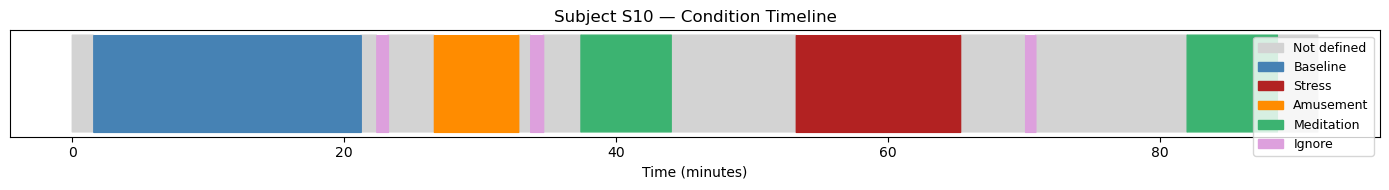

In [24]:
# Convert label indices to time in minutes for the x-axis
time_axis = np.arange(len(data['label'])) / FS_LABEL / 60

# Assign a color to each condition for visual clarity
colors = {
    0: 'lightgrey',
    1: 'steelblue',
    2: 'firebrick',
    3: 'darkorange',
    4: 'mediumseagreen',
    5: 'plum',
    6: 'plum',
    7: 'plum'
}

fig, ax = plt.subplots(figsize=(14, 2))

# Fill the timeline with condition colors
for v in np.unique(data['label']):
    mask = data['label'] == v
    ax.fill_between(time_axis, 0, 1,
                    where=mask,
                    color=colors[int(v)],
                    label=label_names[int(v)])

ax.set_xlabel('Time (minutes)')
ax.set_yticks([])
ax.set_title(f"Subject {data['subject']} — Condition Timeline")

# Deduplicate legend entries since labels 5, 6, 7 share the same name
handles, lbls = ax.get_legend_handles_labels()
seen = {}
for h, l in zip(handles, lbls):
    if l not in seen:
        seen[l] = h
ax.legend(seen.values(), seen.keys(), loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

**Condition durations:** Following the paper's analysis (Schmidt et al., 2018, Section 5), the three conditions of interest (baseline, stress, amusement) together account for approximately 38 minutes per subject (~20 min baseline, ~12 min stress, ~6 min amusement). The remaining ~54 minutes correspond to undefined periods, meditation, and transitions which the paper does not include in its analysis.

**Class imbalance:** Even across the three conditions of interest there is a clear imbalance — baseline has roughly 3x more data than amusement. The paper acknowledges this and uses F1-score as the primary evaluation metric rather than accuracy (Schmidt et al., 2018, Section 4.3).

**Protocol structure:** The timeline confirms that subject S10 followed Version A of the study protocol (Schmidt et al., 2018, Section 3.3) — baseline first, then amusement, then stress. The pink transition segments (labels 5, 6, 7) are clearly visible as thin strips between conditions, confirming the brief inter-condition periods described in the paper.

## Section 5: Visualizing Raw Signals

Now that we understand the label system and the study protocol, we look at the actual signal data. The paper describes physiological responses that should be visible in the signals across conditions — for example, elevated EDA and heart rate during stress compared to baseline (Schmidt et al., 2018, Section 5.2).

We plot 60 seconds of each raw wrist signal during each of the three conditions of interest (baseline, stress, amusement) side by side, following the same conditions used in the paper's analysis. This lets us visually confirm whether the expected physiological differences between conditions are observable in the data.

In [25]:
# Extract raw signals
bvp  = data['signal']['wrist']['BVP'].flatten()
eda  = data['signal']['wrist']['EDA'].flatten()
temp = data['signal']['wrist']['TEMP'].flatten()
acc  = data['signal']['wrist']['ACC']

# Sampling frequencies — confirmed empirically in Section 3
# and consistent with Schmidt et al. (2018), Section 3.2
FS_BVP  = 64
FS_EDA  = 4
FS_TEMP = 4
FS_ACC  = 32

# Conditions and colors for plotting
conditions = {1: 'Baseline', 2: 'Stress', 3: 'Amusement'}
colors     = {1: 'steelblue', 2: 'firebrick', 3: 'darkorange'}

# Window length: 60 seconds at each signal's rate
win_bvp  = 60 * FS_BVP
win_eda  = 60 * FS_EDA   # also used for TEMP since both are at 4 Hz
win_acc  = 60 * FS_ACC

# Find start indices for each condition in label array (at 700 Hz)
# then convert to each signal's index
starts = {}
for label_val in conditions:
    idx_label = np.where(data['label'] == label_val)[0][0]
    starts[label_val] = {
        'bvp':  int(idx_label / FS_LABEL * FS_BVP),
        'eda':  int(idx_label / FS_LABEL * FS_EDA),
        'temp': int(idx_label / FS_LABEL * FS_TEMP),
        'acc':  int(idx_label / FS_LABEL * FS_ACC),
    }

# Time axes
t_bvp = np.arange(win_bvp) / FS_BVP
t_eda = np.arange(win_eda) / FS_EDA   # also used for TEMP
t_acc = np.arange(win_acc) / FS_ACC

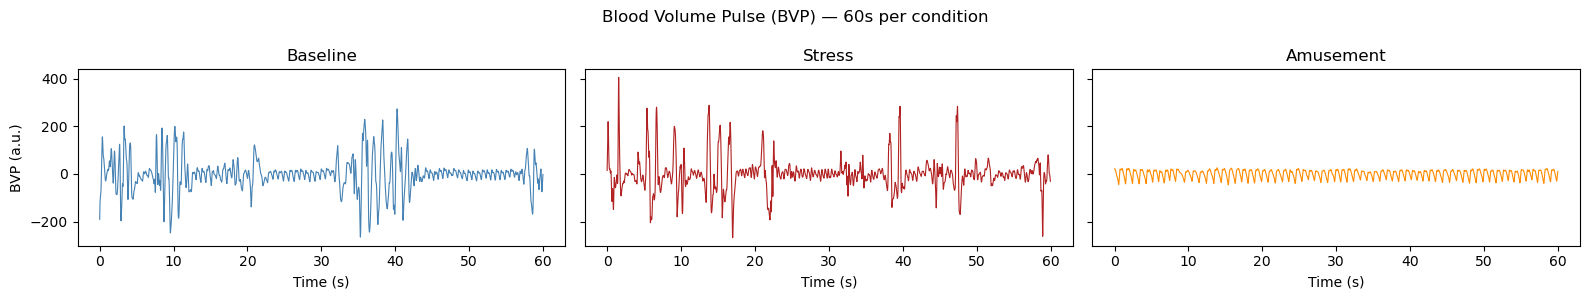

In [26]:
# Plot 60 seconds of raw BVP signal for each condition side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 3), sharey=True)
fig.suptitle('Blood Volume Pulse (BVP) — 60s per condition', fontsize=12)

for ax, (label_val, name) in zip(axes, conditions.items()):
    s = starts[label_val]['bvp']
    ax.plot(t_bvp, bvp[s:s + win_bvp],
            color=colors[label_val], lw=0.8)
    ax.set_title(name)
    ax.set_xlabel('Time (s)')

axes[0].set_ylabel('BVP (a.u.)')
plt.tight_layout()
plt.show()

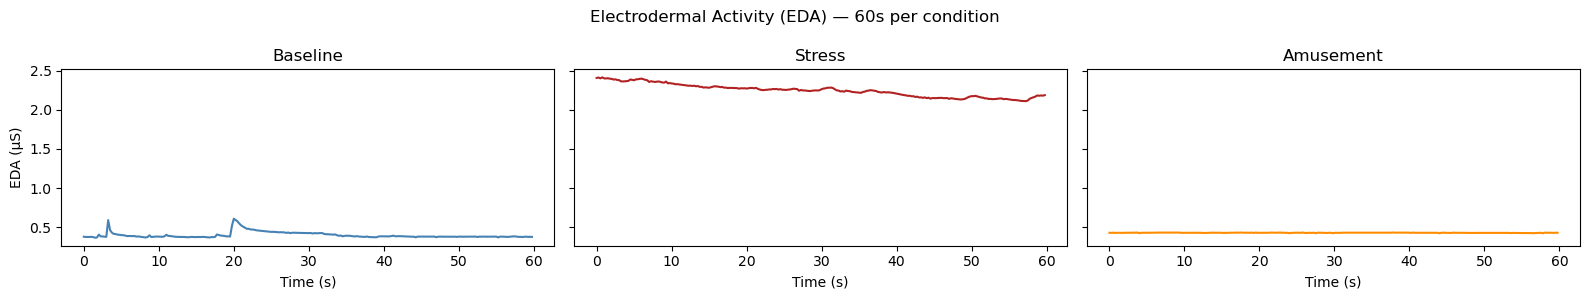

In [27]:
# Plot 60 seconds of raw EDA signal for each condition side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 3), sharey=True)
fig.suptitle('Electrodermal Activity (EDA) — 60s per condition', fontsize=12)

for ax, (label_val, name) in zip(axes, conditions.items()):
    s = starts[label_val]['eda']
    ax.plot(t_eda, eda[s:s + win_eda],
            color=colors[label_val])
    ax.set_title(name)
    ax.set_xlabel('Time (s)')

axes[0].set_ylabel('EDA (μS)')
plt.tight_layout()
plt.show()

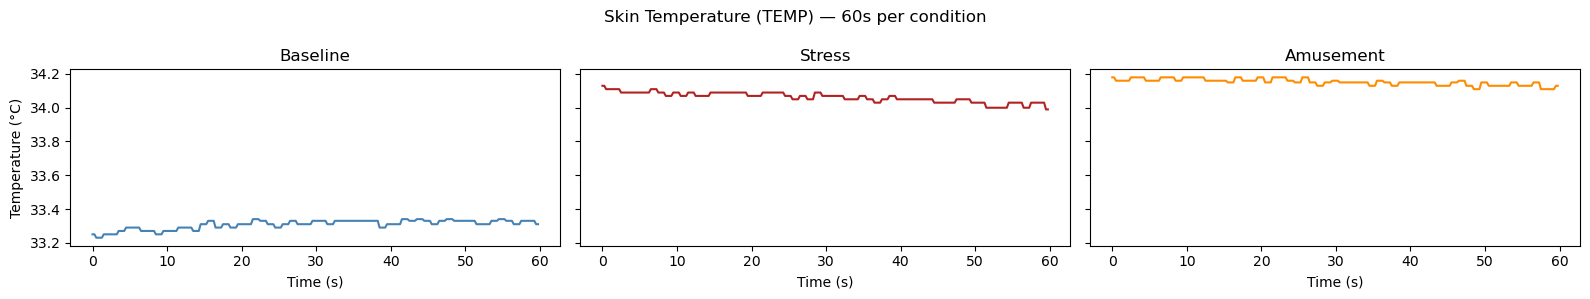

In [28]:
# Plot 60 seconds of raw TEMP signal for each condition side by side
fig, axes = plt.subplots(1, 3, figsize=(16, 3), sharey=True)
fig.suptitle('Skin Temperature (TEMP) — 60s per condition', fontsize=12)

for ax, (label_val, name) in zip(axes, conditions.items()):
    s = starts[label_val]['temp']
    ax.plot(t_eda, temp[s:s + win_eda],
            color=colors[label_val])
    ax.set_title(name)
    ax.set_xlabel('Time (s)')

axes[0].set_ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

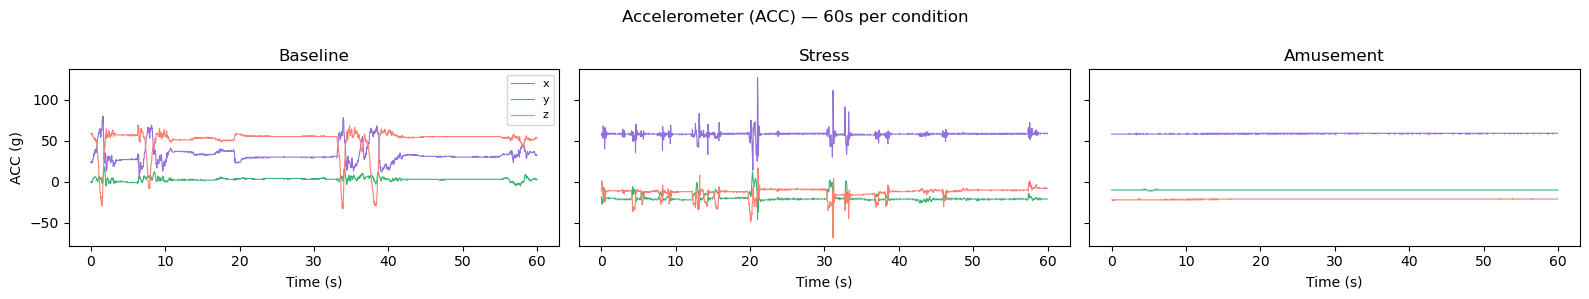

In [29]:
# Plot 60 seconds of raw ACC signal for each condition side by side
# All three axes (x, y, z) are plotted on the same subplot
# ACC has shape (N, 3) confirmed in Section 2 — Schmidt et al. (2018), Section 3.2
fig, axes = plt.subplots(1, 3, figsize=(16, 3), sharey=True)
fig.suptitle('Accelerometer (ACC) — 60s per condition', fontsize=12)

for ax, (label_val, name) in zip(axes, conditions.items()):
    s = starts[label_val]['acc']
    ax.plot(t_acc, acc[s:s + win_acc, 0],
            color='mediumpurple', lw=0.8, label='x')
    ax.plot(t_acc, acc[s:s + win_acc, 1],
            color='mediumseagreen', lw=0.8, label='y')
    ax.plot(t_acc, acc[s:s + win_acc, 2],
            color='salmon', lw=0.8, label='z')
    ax.set_title(name)
    ax.set_xlabel('Time (s)')

axes[0].set_ylabel('ACC (g)')
axes[0].legend(fontsize=8)
plt.tight_layout()
plt.show()

### Section 5: Key Observations

**BVP:** The cardiac waveform is clearly visible in all three conditions.
The amusement condition shows the cleanest, most regular pulse pattern,
while baseline and stress show more variability and occasional large
amplitude spikes likely caused by motion artefacts. This is consistent
with the paper's description of BVP as a signal requiring preprocessing
before feature extraction (Schmidt et al., 2018, Section 4.1).

**EDA:** A clear difference in conductance level is visible across
conditions — stress shows the highest EDA (~2.3 μS), while amusement
is nearly flat and very low. This is consistent with the known role of
EDA as a marker of sympathetic nervous system activation, and aligns
with the paper's finding that EDA is among the more informative wrist
signals for distinguishing affective states (Schmidt et al., 2018,
Section 5.2).

**TEMP:** Skin temperature is very stable within each 60-second window
as expected, but shows a clear difference across conditions — stress
and amusement are both warmer (~34.0°C) than baseline (~33.3°C),
likely reflecting increased peripheral blood flow during arousal states.

**ACC:** The baseline condition shows significant movement at the start
of the window, which then settles. The stress condition shows sharp
motion spikes around 20–30 seconds, possibly corresponding to gestures
during the public speaking task. Amusement is very still. This confirms
that ACC captures postural and movement information rather than
physiological stress responses directly.

## Section 6: Inter-Subject Variability

So far we have only looked at a single subject (S10). The paper notes that physiological signals vary considerably between individuals and highlights large inter-subject differences as a key characteristic of the dataset (Schmidt et al., 2018, Section 5.2). We therefore load all 15 subjects to check whether the observations we made for S10 hold across the full dataset.

We look at two things:
- The condition durations across subjects to confirm the protocol was followed consistently
- The signal amplitude ranges across subjects to understand the degree of inter-subject variability in the raw signals

In [30]:
# Load all subjects
all_subjects_raw = []

for pkl_path in pkl_files:
    subj_id = os.path.basename(os.path.dirname(pkl_path))
    with open(pkl_path, 'rb') as f:
        subj_data = pickle.load(f, encoding='latin1')
    all_subjects_raw.append(subj_data)
    print(f"Loaded {subj_id}")

print(f"\nTotal subjects loaded: {len(all_subjects_raw)}")

Loaded S10
Loaded S11
Loaded S13
Loaded S14
Loaded S15
Loaded S16
Loaded S17
Loaded S2
Loaded S3
Loaded S4
Loaded S5
Loaded S6
Loaded S7
Loaded S8
Loaded S9

Total subjects loaded: 15


The paper describes two versions of the study protocol — Version A (baseline → amusement → stress) and Version B (baseline → stress → amusement) — alternated between subjects to avoid order effects (Schmidt et al., 2018, Section 3.3). We plot the condition timeline for all 15 subjects to visually confirm this.

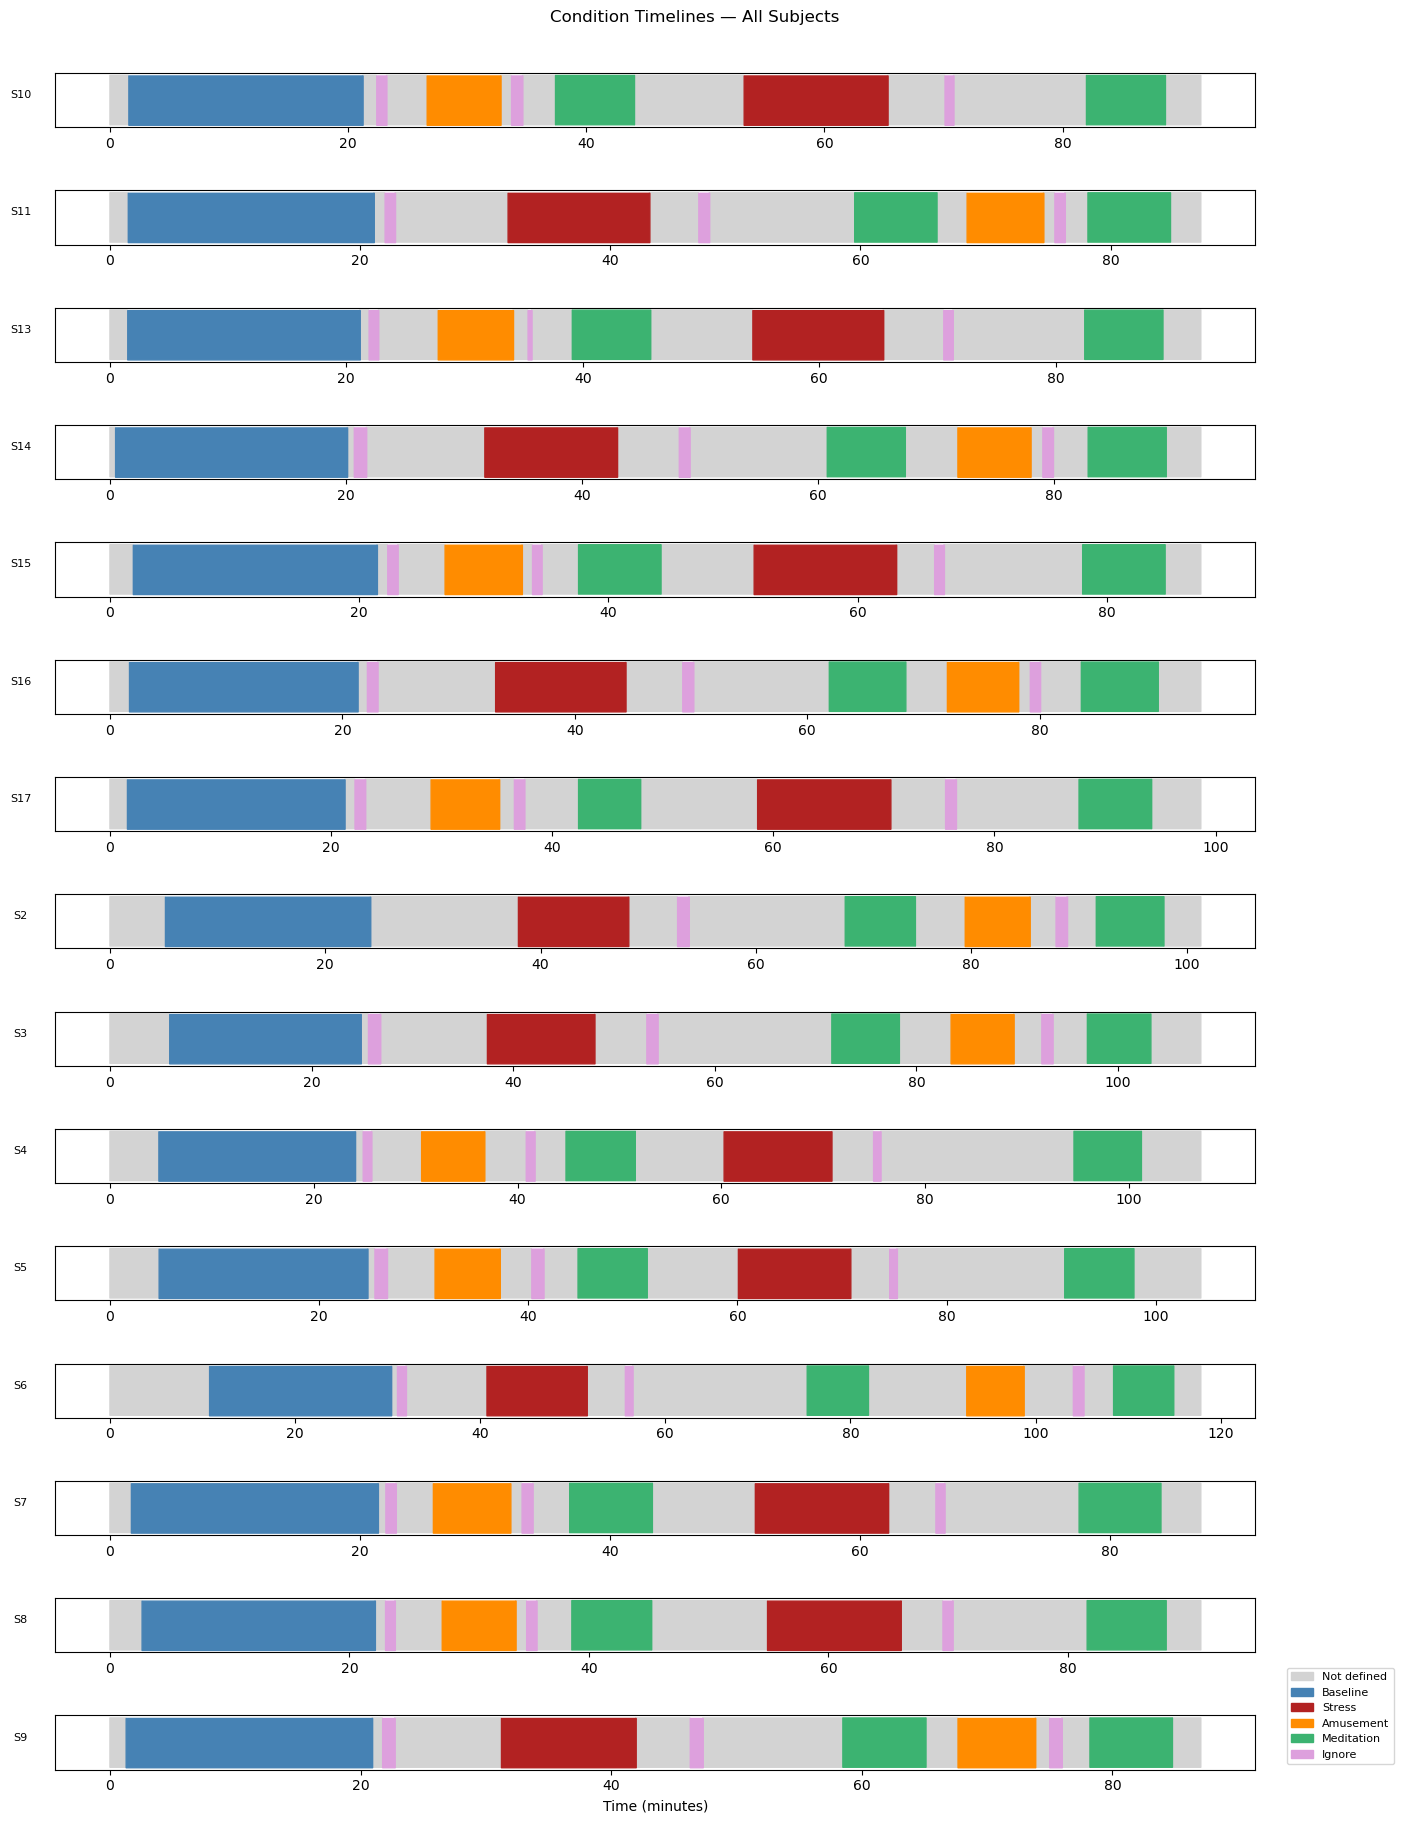

In [31]:
# Plot condition timelines for all 15 subjects

# Full color mapping for all label values
colors_full = {
    0: 'lightgrey',
    1: 'steelblue',
    2: 'firebrick',
    3: 'darkorange',
    4: 'mediumseagreen',
    5: 'plum',
    6: 'plum',
    7: 'plum'
}

fig, axes = plt.subplots(len(all_subjects_raw), 1,
                          figsize=(14, len(all_subjects_raw) * 1.2))
fig.suptitle('Condition Timelines — All Subjects', fontsize=12, y=1.01)

for ax, subj_data in zip(axes, all_subjects_raw):
    labels_subj = subj_data['label']
    time_axis   = np.arange(len(labels_subj)) / FS_LABEL / 60

    for v in np.unique(labels_subj):
        mask = labels_subj == v
        ax.fill_between(time_axis, 0, 1,
                        where=mask,
                        color=colors_full[int(v)],
                        label=label_names[int(v)])
    ax.set_ylabel(subj_data['subject'], fontsize=8, rotation=0, labelpad=25)
    ax.set_yticks([])

# Add legend using last axis
handles, lbls = axes[-1].get_legend_handles_labels()
seen = {}
for h, l in zip(handles, lbls):
    if l not in seen:
        seen[l] = h
axes[-1].legend(seen.values(), seen.keys(),
                loc='lower right', fontsize=8,
                bbox_to_anchor=(1.12, 0))

axes[-1].set_xlabel('Time (minutes)')
plt.tight_layout()
plt.show()

The timelines confirm the two protocol versions described in Schmidt et al. (2018), Section 3.3 and Figure 2:

- **Version A** (baseline → amusement → stress): S10, S13, S15, S17, S4, S5, S7, S8
- **Version B** (baseline → stress → amusement): S11, S14, S16, S2, S3, S6, S9

The order was alternated between subjects to avoid effects of order, exactly as the paper describes. All subjects show the same baseline period at the start, followed by the two affective conditions in alternating order, each separated by a meditation period.

One notable observation is that some subjects (S2, S3, S4, S5, S6) have considerably longer "not defined" periods (grey) compared to others, pushing the total recording duration beyond 100 minutes in some cases. This is consistent with the variability in total recording duration noted in the dataset and does not affect the usable condition data, which remains consistent across all subjects as confirmed by the duration table.

In [32]:
# Compare label distributions across all subjects
# Build a summary table of condition durations for all subjects
# Give labels 5, 6, 7 distinct names to avoid duplicate pivot entries
label_names_unique = {
    0: 'Not defined',
    1: 'Baseline',
    2: 'Stress',
    3: 'Amusement',
    4: 'Meditation',
    5: 'Ignore_5',
    6: 'Ignore_6',
    7: 'Ignore_7',
}

rows = []
for subj_data in all_subjects_raw:
    subj_id = subj_data['subject']
    for v, name in label_names_unique.items():
        n       = int(np.sum(subj_data['label'] == v))
        dur_min = n / FS_LABEL / 60
        rows.append({
            'Subject':        subj_id,
            'Label':          v,
            'Condition':      name,
            'Duration (min)': round(dur_min, 1)
        })

df_labels = pd.DataFrame(rows)

# Pivot to show one row per subject, one column per condition
df_pivot = df_labels.pivot(index='Subject',
                            columns='Condition',
                            values='Duration (min)')
print(df_pivot.to_string())

Condition  Amusement  Baseline  Ignore_5  Ignore_6  Ignore_7  Meditation  Not defined  Stress
Subject                                                                                      
S10              6.2      19.7       0.8       0.8       0.9        13.3         37.8    12.1
S11              6.1      19.7       0.8       0.9       0.8        13.2         34.4    11.3
S13              6.4      19.7       0.8       0.8       0.3        13.2         40.0    11.1
S14              6.2      19.7       1.1       0.9       0.9        13.2         39.2    11.2
S15              6.2      19.6       0.8       0.8       0.8        13.2         34.7    11.4
S16              6.1      19.7       0.9       0.9       0.9        13.2         40.9    11.2
S17              6.2      19.7       1.0       1.0       0.9        12.2         45.7    12.1
S2               6.0      19.1       0.0       1.1       1.1        12.8         51.0    10.2
S3               6.2      19.0       1.2       1.1       1.1

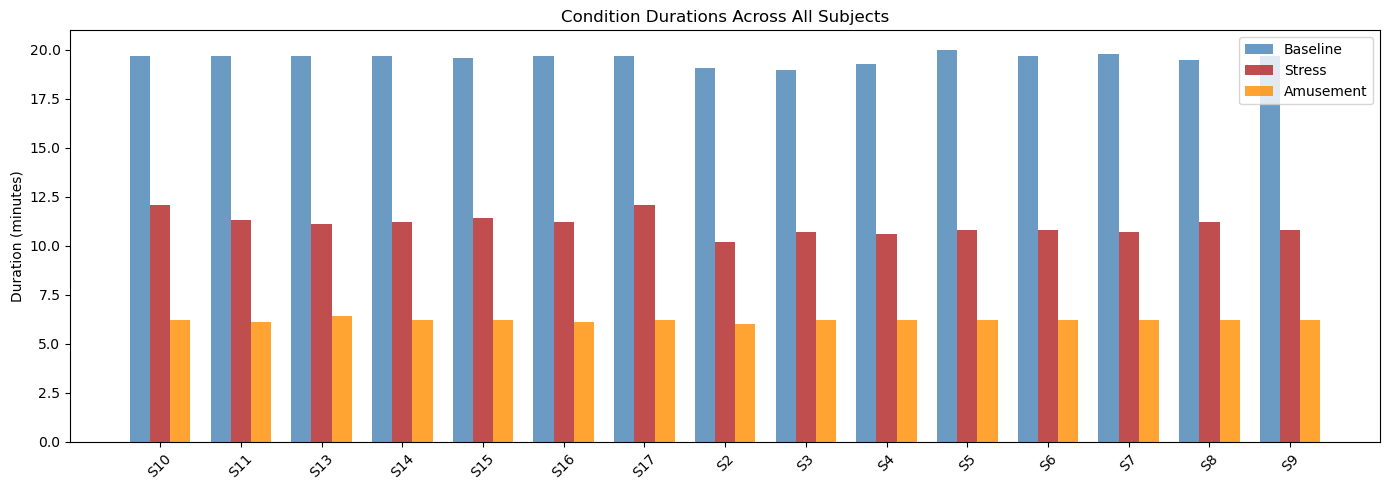

In [33]:
# Plot condition durations for the three affective conditions of interest
# (baseline, stress, amusement) across all subjects
conditions_to_plot = ['Baseline', 'Stress', 'Amusement']
plot_colors = ['steelblue', 'firebrick', 'darkorange']

fig, ax = plt.subplots(figsize=(14, 5))

x = np.arange(len(all_subjects_raw))
width = 0.25

for i, (cond, color) in enumerate(zip(conditions_to_plot, plot_colors)):
    values = df_pivot[cond].values
    ax.bar(x + i * width, values, width=width,
           label=cond, color=color, alpha=0.8)

ax.set_xticks(x + width)
ax.set_xticklabels(df_pivot.index, rotation=45)
ax.set_ylabel('Duration (minutes)')
ax.set_title('Condition Durations Across All Subjects')
ax.legend()
plt.tight_layout()
plt.show()

We examine inter-subject variability for BVP, EDA, and TEMP only. ACC is excluded from this analysis because its magnitude is dominated by the gravitational component — the Empatica E4 is worn on the wrist and gravity contributes a near-constant offset to the measured acceleration regardless of the subject or condition. ACC therefore does not reflect physiological differences between individuals but rather captures posture and movement, which are inherently inconsistent across subjects and conditions by design (Schmidt et al., 2018, Section 3.3 explicitly states that conditions were conducted either standing or sitting). BVP, EDA, and TEMP on the other hand are purely physiological signals whose baseline levels are expected to vary between people, making them the relevant signals for assessing inter-subject variability.

In [34]:
# For each subject compute the mean and std of each wrist signal during the stress condition only
rows = []
for subj_data in all_subjects_raw:
    subj_id    = subj_data['subject']
    labels_raw = subj_data['label']

    # Find stress indices at each signal's rate
    stress_mask_label = labels_raw == 2
    stress_idx_start  = np.where(stress_mask_label)[0][0]

    bvp  = subj_data['signal']['wrist']['BVP'].flatten()
    eda  = subj_data['signal']['wrist']['EDA'].flatten()
    temp = subj_data['signal']['wrist']['TEMP'].flatten()

    # Convert start index to each signal's rate
    s_bvp = int(stress_idx_start / FS_LABEL * FS_BVP)
    s_eda = int(stress_idx_start / FS_LABEL * FS_EDA)

    # Take 5 minutes of stress signal for comparison
    w_bvp = 5 * 60 * FS_BVP
    w_eda = 5 * 60 * FS_EDA

    rows.append({
        'Subject':  subj_id,
        'BVP mean': round(np.mean(bvp[s_bvp:s_bvp + w_bvp]), 2),
        'BVP std':  round(np.std(bvp[s_bvp:s_bvp + w_bvp]), 2),
        'EDA mean': round(np.mean(eda[s_eda:s_eda + w_eda]), 2),
        'EDA std':  round(np.std(eda[s_eda:s_eda + w_eda]), 2),
        'TEMP mean':round(np.mean(temp[s_eda:s_eda + w_eda]), 2),
        'TEMP std': round(np.std(temp[s_eda:s_eda + w_eda]), 2),
    })

df_variability = pd.DataFrame(rows).set_index('Subject')
print(df_variability.to_string())

         BVP mean  BVP std  EDA mean  EDA std  TEMP mean  TEMP std
Subject                                                           
S10          0.07    59.78      2.67     0.42      33.84      0.16
S11          0.11    37.09      3.04     0.14      33.44      0.19
S13         -0.27   162.72     12.84     1.27      34.12      0.28
S14         -0.12    43.64      0.34     0.01      32.73      0.06
S15         -0.07   139.52      1.20     0.17      30.18      0.04
S16         -0.01    20.61      2.05     0.34      31.08      0.06
S17         -0.09    63.03      1.04     0.03      32.43      0.17
S2           0.10    98.00      0.68     0.08      33.84      0.17
S3           0.03    18.11      2.74     1.74      32.48      0.12
S4          -0.04    81.65      2.34     0.33      32.61      0.09
S5          -0.02   165.68      3.13     0.47      33.99      0.16
S6          -0.13    50.00      8.83     0.45      33.22      0.16
S7           0.02    70.75      6.56     0.25      33.06      

For BVP we report the standard deviation rather than the mean, because BVP is an AC-coupled signal centered around zero for all subjects — the mean is therefore always close to zero and carries no useful information. The standard deviation reflects the signal amplitude, which does vary meaningfully between subjects.

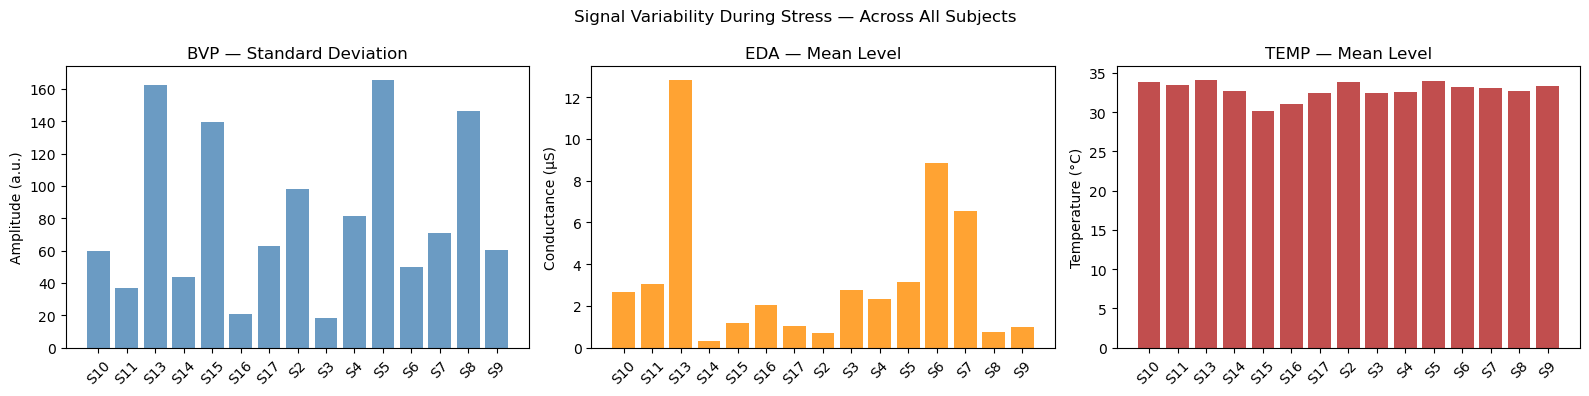

In [35]:
# Visualize inter-subject variability for the three physiological signals
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Signal Variability During Stress — Across All Subjects', fontsize=12)

# BVP: plot std since mean is always ~0 (AC-coupled signal)
axes[0].bar(df_variability.index, df_variability['BVP std'],
            color='steelblue', alpha=0.8)
axes[0].set_title('BVP — Standard Deviation')
axes[0].set_ylabel('Amplitude (a.u.)')
axes[0].tick_params(axis='x', rotation=45)

# EDA: plot mean since absolute conductance level is meaningful
axes[1].bar(df_variability.index, df_variability['EDA mean'],
            color='darkorange', alpha=0.8)
axes[1].set_title('EDA — Mean Level')
axes[1].set_ylabel('Conductance (μS)')
axes[1].tick_params(axis='x', rotation=45)

# TEMP: plot mean since absolute temperature is meaningful
axes[2].bar(df_variability.index, df_variability['TEMP mean'],
            color='firebrick', alpha=0.8)
axes[2].set_title('TEMP — Mean Level')
axes[2].set_ylabel('Temperature (°C)')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Protocol consistency:** The condition duration table confirms that the study protocol was followed consistently across all 15 subjects. Baseline is always approximately 20 minutes, stress approximately 11–12 minutes, and amusement approximately 6 minutes. This consistency is important because it means the class imbalance we observed for S10 is not specific to that subject — it is a structural property of the dataset that will affect all subjects equally.

**Inter-subject variability:** The signal variability plots reveal substantial differences between subjects, particularly for BVP and EDA:

**BVP:** The mean is close to zero for all subjects as expected for an AC-coupled signal, but the standard deviation varies enormously — from 18 (S3, S16) to 165 (S5), almost a 10x difference. This means some subjects produce much stronger pulse waveforms than others.

**EDA:** Shows the most dramatic inter-subject variability. Mean conductance during stress ranges from 0.34 μS (S14) to 12.84 μS (S13), a nearly 40x difference. This is well-known in the literature — EDA responses vary greatly between individuals due to differences in sweat gland density and sympathetic nervous system reactivity.

**TEMP:** Is the most consistent signal across subjects, ranging from approximately 30°C to 34°C, though still showing meaningful variation.

**Implication for preprocessing:** The large inter-subject variability in BVP and EDA means that without normalization, a model trained on raw signal features could learn to distinguish subjects rather than stress conditions. This motivates the use of **subject-level z-score normalization** in the preprocessing pipeline, which will be applied later.